In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/merged_clean.csv")

In [6]:
df.shape
df.head()

,QKEY,COVIDMISINFO_W63.5,COVIDCREATE_W63.5,F_PARTYSUM_FINAL,F_IDEO,F_AGECAT,F_EDUCCAT,WEIGHT_W63.5,VOTEGEN_POST_W78,covid_misinfo_belief,trump_vote
0,100197.0,Some,Not sure,Dem/Lean Dem,Moderate,65+,Some College,0.326265,"Joe Biden, the Democrat",NaN,0.0
1,100260.0,Some,Was developed intentionally in a lab,Rep/Lean Rep,Very conservative,65+,College graduate+,0.655627,"Donald Trump, the Republican",1.0,1.0
2,100314.0,Not much,Was made accidentally in a lab,Rep/Lean Rep,Moderate,65+,Some College,0.432865,"Donald Trump, the Republican",NaN,1.0
3,100363.0,None at all,Came about naturally,Dem/Lean Dem,Moderate,30-49,College graduate+,0.396183,"Joe Biden, the Democrat",0.0,0.0
4,100446.0,Not much,Not sure,Dem/Lean Dem,Liberal,50-64,College graduate+,0.392344,"Joe Biden, the Democrat",NaN,0.0


In [8]:
# regression model 1

reg1 = df[["covid_misinfo_belief", "trump_vote"]].dropna()
reg1.shape

(5079, 2)

In [12]:
reg1.trump_vote.value_counts()
reg1.covid_misinfo_belief.value_counts()

covid_misinfo_belief
0.0    3943
1.0    1136
Name: count, dtype: int64

In [13]:
import statsmodels.formula.api as smf

In [14]:
# run model
model1 = smf.logit("trump_vote ~ covid_misinfo_belief", data=reg1).fit()

Optimization terminated successfully.
         Current function value: 0.590116
         Iterations 5


In [15]:
model1.summary()
# positve coefficient 1.6765 -> 1 respondents (misinfo) more likely to vote for Trump than 0 (came naturally)
# small p value (<0.001) -> statistically significant

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             trump_vote   No. Observations:                 5079
Model:                          Logit   Df Residuals:                     5077
Method:                           MLE   Df Model:                            1
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                 0.08775
Time:                        20:28:36   Log-Likelihood:                -2997.2
converged:                       True   LL-Null:                       -3285.5
Covariance Type:            nonrobust   LLR p-value:                2.073e-127
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -1.0396      0.036    -28.678      0.000      -1.111      -0.969
covid_misinfo_belief     1.6765      0.072     23.239      0.000       1.535       1.818
========================================================================================
"""

In [16]:
np.exp(model1.params) # exponentiate coefficient
# odds of voting for Trump are about 5.35x as high for misinfo believers

Intercept               0.353587
covid_misinfo_belief    5.346869
dtype: float64

In [18]:
# regression model 2 - control for political party (check for confounding in model 1)

df["F_PARTYSUM_FINAL"].value_counts(dropna=False)

reg2 = df[["trump_vote", "covid_misinfo_belief", "F_PARTYSUM_FINAL"]].dropna()
reg2.shape

(5079, 3)

In [19]:
model2 = smf.logit('trump_vote ~ covid_misinfo_belief + C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))', data=reg2).fit()
model2.summary()

# coefficient drops to 1.2816 - still positive and statistically significant (p < 0.001)

Optimization terminated successfully.
         Current function value: 0.189497
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:             trump_vote   No. Observations:                 5079
Model:                          Logit   Df Residuals:                     5075
Method:                           MLE   Df Model:                            3
Date:                Sun, 23 Aug 2026   Pseudo R-squ.:                  0.7071
Time:                        21:00:04   Log-Likelihood:                -962.46
converged:                       True   LL-Null:                       -3285.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
==================================================================================================================================================
                                                                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                         -4.0937      0.133    -30.699      0.000      -4.355      -3.832
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.DK/Refused/No lean]     2.3954      0.346      6.919      0.000       1.717       3.074
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.Rep/Lean Rep]           5.8419      0.147     39.787      0.000       5.554       6.130
covid_misinfo_belief                                                               1.2816      0.153      8.386      0.000       0.982       1.581
==================================================================================================================================================
"""

In [20]:
# exponentiate coefficient
np.exp(model2.params)
# odds of voting for Trump are about 3.6x as high for misinfo believers after controlling for politcal affiliations
# republican coefficient was 5.8419 - explains confounding in model 1

Intercept                                                                           0.016677
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.DK/Refused/No lean]     10.972674
C(F_PARTYSUM_FINAL, Treatment(reference="Dem/Lean Dem"))[T.Rep/Lean Rep]          344.429452
covid_misinfo_belief                                                                3.602282
dtype: float64

In [21]:
# calculating predicted probabilities from model 2
# for each party, predicted probability of voting for Trump if believed/didn't believe misinformation

# data frame
pred_df = pd.DataFrame({"covid_misinfo_belief": [0, 1, 0, 1, 0, 1], "F_PARTYSUM_FINAL": ["Dem/Lean Dem", "Dem/Lean Dem",
                                                                                         "Rep/Lean Rep", "Rep/Lean Rep",
                                                                                         "DK/Refused/No lean", "DK/Refused/No lean"]})

pred_df

,covid_misinfo_belief,F_PARTYSUM_FINAL
0,0,Dem/Lean Dem
1,1,Dem/Lean Dem
2,0,Rep/Lean Rep
3,1,Rep/Lean Rep
4,0,DK/Refused/No lean
5,1,DK/Refused/No lean


In [22]:
# adding predictions to df

pred_df["predicted_prob"] = model2.predict(pred_df)
pred_df

,covid_misinfo_belief,F_PARTYSUM_FINAL,predicted_prob
0,0,Dem/Lean Dem,0.016404
1,1,Dem/Lean Dem,0.056672
2,0,Rep/Lean Rep,0.851724
3,1,Rep/Lean Rep,0.953900
4,0,DK/Refused/No lean,0.154688
5,1,DK/Refused/No lean,0.397300


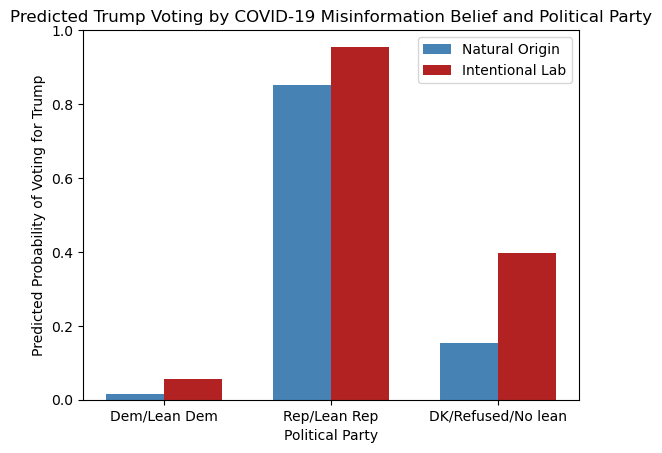

In [23]:
# plotting grouped bar chart from pred_df

# separate misinfo belief into two groups
natural = pred_df[pred_df["covid_misinfo_belief"] == 0]
intentional = pred_df[pred_df["covid_misinfo_belief"] == 1]

# bar positions
x = np.arange(len(natural))
width = 0.35

# two sets of bars
plt.bar(x - width/2, natural["predicted_prob"], width, label="Natural Origin", color="steelblue")
plt.bar(x + width/2, intentional["predicted_prob"], width, label="Intentional Lab", color="firebrick")


plt.xticks(x, natural["F_PARTYSUM_FINAL"])
plt.xlabel("Political Party")
plt.ylabel("Predicted Probability of Voting for Trump")
plt.title("Predicted Trump Voting by COVID-19 Misinformation Belief and Political Party")
plt.legend()
plt.ylim(0, 1) # probabilities can only range from 0-1

plt.savefig("../output/predicted_trump_vote.png", bbox_inches="tight")

plt.show()